In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import nan
from functions import * # import functions from the .py file

from pylab import rcParams
rcParams["figure.figsize"] = 16, 4

PAYLOADSIZE_ENCODED = 26 #25/24 gives BER 22%
PAYLOADSIZE_DECODED = 14

if PAYLOADSIZE_DECODED % 2 != 0:
    print("Alarm! the payload size is not even.")
NUM_16RND = (PAYLOADSIZE_DECODED-2)//2 # how many 16 bits random number included in each frame
MAX_SEQ = 256 # (decimal) maximum seq number defined by the length of the seq, the length of seq is 1B

files = [
    "opt1/opt1-50cm.csv",
    "opt1/opt1-100cm.csv",
    "opt1/opt1-150cm.csv",
    "opt1/opt1-200cm.csv",
    "opt1/opt1-250cm.csv",
]

distance = []
ber_list = []
pdr_list = []
rssi_list = []
rate_list = []
pxtx_list = []
delay_list = []

for f in files:
    df = readfile("./" + f)

    if len(df) == 0:
        continue

    # time
    file_delay = df.time_rx.iloc[-1] - df.time_rx.iloc[0]
    file_delay_s = np.timedelta64(file_delay, "ms").astype(int) / 1000

    # BER
    test = df[df.payload.apply(lambda x: len(x) == ((26) * 3 - 1))]
    test.reset_index(inplace=True)

    ber = compute_ber(test, PACKET_LEN=NUM_16RND * 2)
    print(f"BER: {ber}")
    ber_list.append(ber * 100)

    # PDR (packet delivery ratio)
    pdr_list.append((len(test) / len(df)) * 100 if len(df) > 0 else 0)

    # RSSI
    rssi_values = df["rssi"].dropna()
    rssi_list.append(rssi_values.mean() if len(rssi_values) > 0 else np.nan)

    # Data rate
    rate_list.append((len(df) * NUM_16RND * 2 / file_delay_s) if file_delay_s > 0 else 0)

    # distance from filename
    dist = int(f.split("-")[-1].replace("cm.csv", ""))
    distance.append(dist)

    pxtx_list.append(packets_transmitted(df))

    file_delay = df.time_rx[len(df) - 1] - df.time_rx[0]
    file_delay_s = np.timedelta64(file_delay, "ms").astype(int) / 1000
    delay_list.append(file_delay_s)

# sort by distance
distance, ber_list, pdr_list, rssi_list, rate_list = zip(
    *sorted(zip(distance, ber_list, pdr_list, rssi_list, rate_list))
)

distance = list(distance)
ber = list(ber_list)
pdr = list(pdr_list)
rssi = list(rssi_list)
rate = list(rate_list)
pxtx = list(pxtx_list)
delay = list(delay_list)


len df before: ['1a', '01', 'ca', '95', '4a', '95', '54', '02', '66', '4a', '93', '20', '92', '24', '1c', '6a', 'cb', 'd6', '61', '86', 'cf', '54', '55', '00', 'c0', '21', '03', '00']
df before: 1a 01 ca 95 4a 95 54 02 66 4a 93 20 92 24 1c 6a cb d6 61 86 cf 54 55 00 c0 21 03 00
len payload after: 26
payload after: ca 95 4a 95 54 02 66 4a 93 20 92 24 1c 6a cb d6 61 86 cf 54 55 00 c0 21 03 00
pseudoseq: 51861
df_row.payload: ca 95 4a 95 54 02 66 4a 93 20 92 24 1c 6a cb d6 61 86 cf 54 55 00 c0 21 03 00
len payload: 26
payload:  4a 95 54 02 66 4a 93 20 92 24 1c 6a cb d6 61 86 cf 54 55 00 c0 21 03 00
expected: 13 5d 1f 43 1b 45 25 6f 21 fe 0f 7e
pseudoseq: 52133
df_row.payload: cb a5 47 b5 64 02 66 4b 33 60 b6 3c 1c 66 cb d6 61 86 4f 54 55 00 c0 21 03 00
len payload: 26
payload:  47 b5 64 02 66 4b 33 60 b6 3c 1c 66 cb d6 61 86 4f 54 55 00 c0 21 03 00
expected: 13 5d 1f 43 1b 45 25 6f 21 fe 0f 7e
pseudoseq: 52133
df_row.payload: cb a5 46 b5 64 02 66 4b 33 56 d6 af 55 56 df f5 61 86 cf 54 55 

### BER-Distance

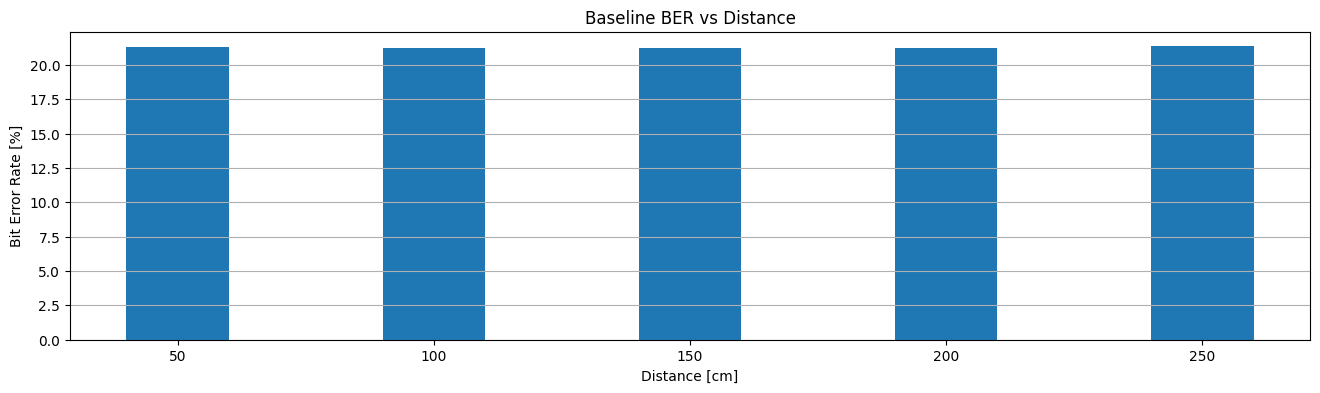

In [10]:
plt.figure()
plt.bar(distance, ber, width=20)
plt.xlabel("Distance [cm]")
plt.ylabel("Bit Error Rate [%]")
plt.title("Baseline BER vs Distance")
plt.grid(axis='y')
plt.show()

### PDR-Distance

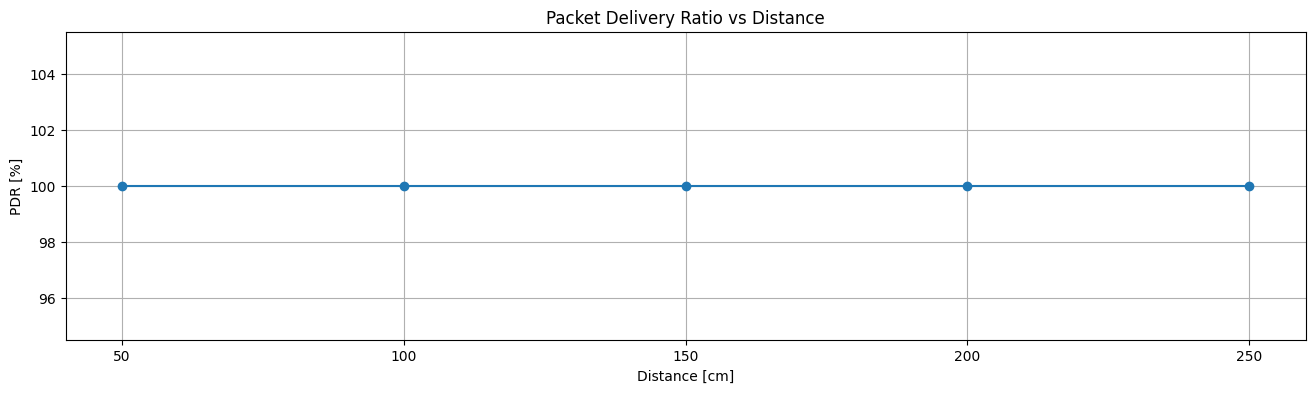

In [11]:
plt.figure()
plt.plot(distance, pdr, marker='o')
plt.xlabel("Distance [cm]")
plt.ylabel("PDR [%]")
plt.title("Packet Delivery Ratio vs Distance")
plt.grid()
plt.xticks(distance)
plt.show()

### PER-Distance??

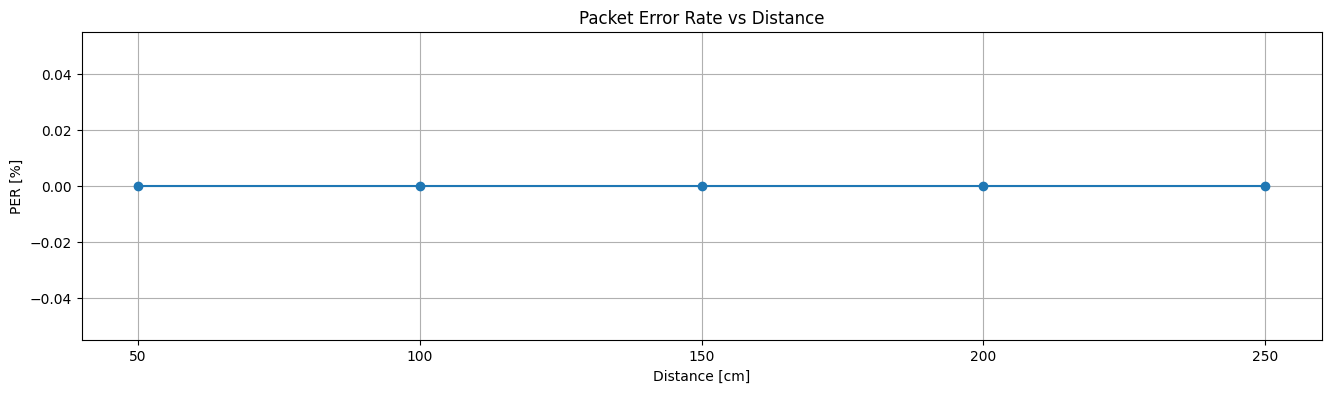

In [12]:
per = [100 - x for x in pdr]

plt.figure()
plt.plot(distance, per, marker='o')
plt.xlabel("Distance [cm]")
plt.ylabel("PER [%]")
plt.title("Packet Error Rate vs Distance")
plt.grid()
plt.xticks(distance)
plt.show()

### RSSI-Distance

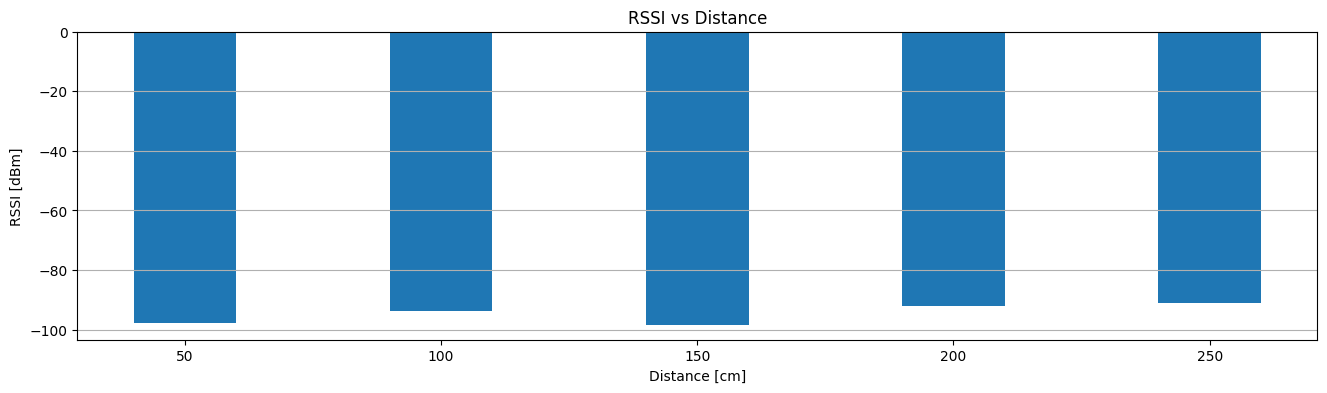

In [13]:
plt.figure()
plt.bar(distance, rssi, width=20)
plt.xlabel("Distance [cm]")
plt.ylabel("RSSI [dBm]")
plt.title("RSSI vs Distance")
plt.grid(axis='y')
plt.xticks(distance)
plt.show()

Data Rate-Distance

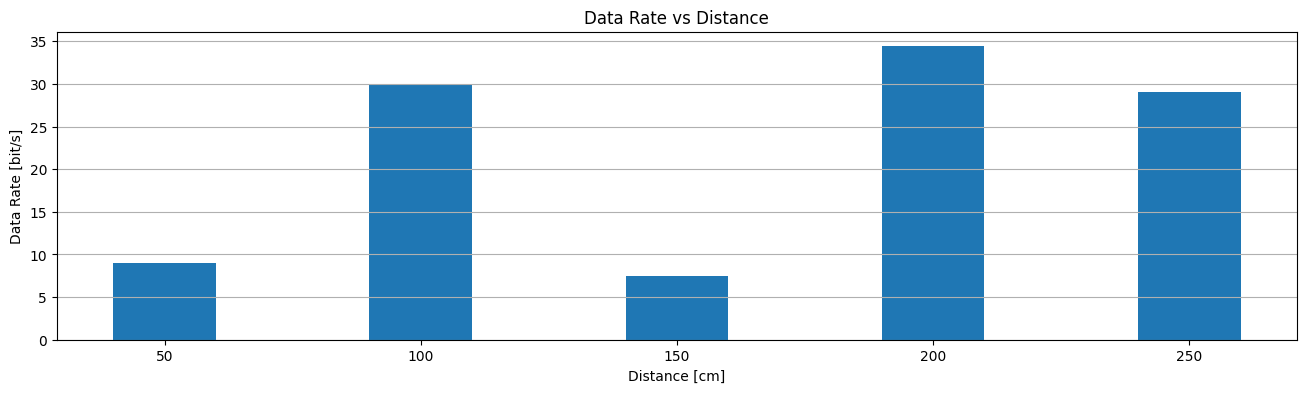

In [14]:
plt.figure()
plt.bar(distance, rate, width=20)
plt.xlabel("Distance [cm]")
plt.ylabel("Data Rate [bit/s]")
plt.title("Data Rate vs Distance")
plt.grid(axis='y')
plt.xticks(distance)
plt.show()

### RSSI-BER with Distance markers

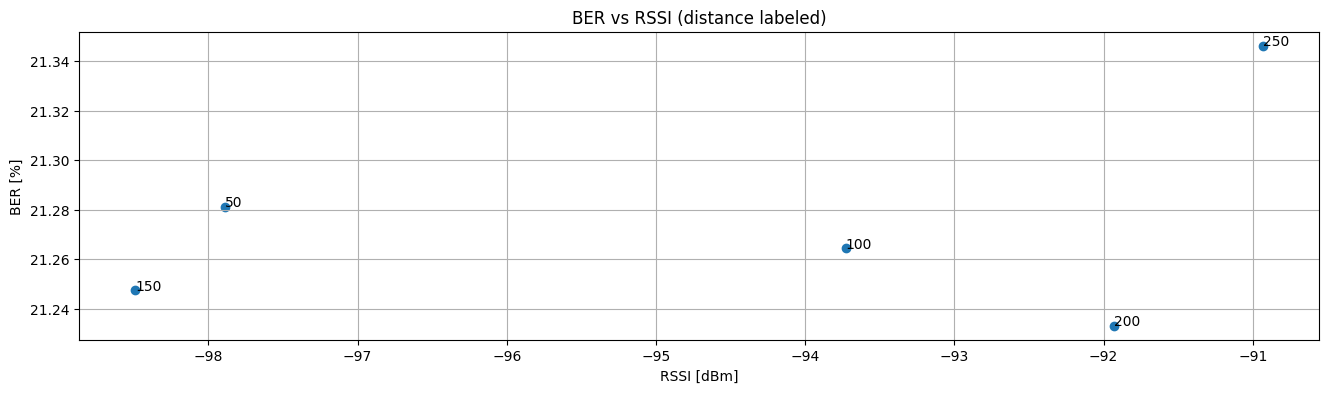

In [15]:
plt.figure()
plt.scatter(rssi, ber)

for i in range(len(distance)):
    plt.text(rssi[i], ber[i], f"{distance[i]}")

plt.xlabel("RSSI [dBm]")
plt.ylabel("BER [%]")
plt.title("BER vs RSSI (distance labeled)")
plt.grid()

plt.show()

### Latex result table

In [16]:
table_df = pd.DataFrame({
    "Dist. [cm]": distance,
    "Delay [s]": delay,
    "Px Tx": pxtx,
    "BER [\%]": ber,
    "Rate [bit/s]": rate,
    "RSSI [dBm]": rssi
})


latex_table = table_df.to_latex(
    index=False,
    column_format="|S|S|S|S|S|S|",
    escape=False,
    float_format="%.2f"
)

print(latex_table)

\begin{tabular}{|S|S|S|S|S|S|}
\toprule
Dist. [cm] & Delay [s] & Px Tx & BER [\%] & Rate [bit/s] & RSSI [dBm] \\
\midrule
50 & 267.07 & 8 & 21.28 & 8.99 & -97.89 \\
100 & 79.87 & 53 & 21.26 & 30.05 & -93.73 \\
150 & 321.00 & 219 & 21.25 & 7.48 & -98.49 \\
200 & 69.76 & 14 & 21.23 & 34.41 & -91.93 \\
250 & 82.44 & 224 & 21.35 & 29.11 & -90.94 \\
\bottomrule
\end{tabular}



<>:5: SyntaxWarning: invalid escape sequence '\%'
<>:5: SyntaxWarning: invalid escape sequence '\%'
C:\Users\tuvab\AppData\Local\Temp\ipykernel_24824\372953828.py:5: SyntaxWarning: invalid escape sequence '\%'
  "BER [\%]": ber,
